# F1 Race Strategy Intelligence — Phase 2: EDA & Statistical Analysis
**Data:** 2023 Season (3 rounds: Bahrain, Saudi Arabia, Australia)  
**Goal:** Uncover patterns in lap performance, tire strategy, pit stops, and race outcomes  
**Sections:**
1. Setup & Data Loading
2. Data Cleaning
3. Race Outcomes Overview
4. Qualifying → Finish Correlation
5. Tire Compound Analysis
6. Pit Stop Strategy Analysis
7. Lap Time Degradation by Tire
8. Weather Impact
9. Driver Performance Rating (simple ELO-style)
10. Key Findings Summary

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, kruskal
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# F1 team colors for charts
TEAM_COLORS = {
    'Red Bull Racing': '#3671C6',
    'Mercedes':        '#6CD3BF',
    'Ferrari':         '#E8002D',
    'McLaren':         '#FF8000',
    'Aston Martin':    '#358C75',
    'Alpine':          '#2293D1',
    'Williams':        '#37BEDD',
    'AlphaTauri':      '#5E8FAA',
    'Alfa Romeo':      '#C92D4B',
    'Haas F1 Team':    '#B6BABD',
}

COMPOUND_COLORS = {'SOFT': '#E8002D', 'MEDIUM': '#FFF200', 'HARD': '#FFFFFF'}
COMPOUND_ORDER  = ['SOFT', 'MEDIUM', 'HARD']

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load CSVs from Phase 1 ────────────────────────────────────────────────────
# Adjust the path if your f1_data folder is elsewhere
DATA_DIR = 'f1_data'

laps    = pd.read_csv(f'{DATA_DIR}/2023_laps.csv')
pits    = pd.read_csv(f'{DATA_DIR}/2023_pits.csv')
results = pd.read_csv(f'{DATA_DIR}/2023_results.csv')
weather = pd.read_csv(f'{DATA_DIR}/2023_weather.csv')

print(f'Laps:    {len(laps):,} rows')
print(f'Pits:    {len(pits):,} rows')
print(f'Results: {len(results):,} rows')
print(f'Weather: {len(weather):,} rows')
print(f'Rounds:  {sorted(laps["EventName"].unique())}')

Laps:    3,002 rows
Pits:    142 rows
Results: 60 rows
Weather: 531 rows
Rounds:  ['Australian Grand Prix', 'Bahrain Grand Prix', 'Saudi Arabian Grand Prix']


## 2. Data Cleaning

In [3]:
# ── Laps cleaning ─────────────────────────────────────────────────────────────

# Drop laps with no recorded time (pit-out laps, red flag laps, first lap sector gaps)
laps_clean = laps.dropna(subset=['LapTimeSec']).copy()
print(f'Laps dropped (no time): {len(laps) - len(laps_clean)}')

# Remove outlier laps: safety car laps are 30%+ slower than median
# TrackStatus 4 = Safety Car, 6 = VSC, anything >1 is caution
median_lap = laps_clean['LapTimeSec'].median()
laps_clean = laps_clean[
    (laps_clean['LapTimeSec'] < median_lap * 1.30) &  # remove safety car laps
    (laps_clean['TrackStatus'] == 1)                   # green flag only
].copy()
print(f'Laps after SC/VSC filter: {len(laps_clean):,}')

# Also remove pit-in and pit-out laps (inflated times)
laps_racing = laps_clean[
    laps_clean['PitInTime'].isna() & laps_clean['PitOutTime'].isna()
].copy()
print(f'Pure racing laps (no pit): {len(laps_racing):,}')

# ── Results cleaning ──────────────────────────────────────────────────────────

# Simplify Status to 3 buckets
results['Outcome'] = results['Status'].map(
    lambda s: 'Finished' if s == 'Finished' else ('Lapped' if s == 'Lapped' else 'DNF')
)

# Position delta: positive = gained places, negative = lost places
results['PositionDelta'] = results['GridPosition'] - results['Position']

# ── Weather cleaning ──────────────────────────────────────────────────────────
weather['AirTemp']   = pd.to_numeric(weather['AirTemp'],   errors='coerce')
weather['TrackTemp'] = pd.to_numeric(weather['TrackTemp'], errors='coerce')
weather['Rainfall']  = weather['Rainfall'].astype(str).str.lower().map(
    {'true': True, 'false': False}
)

print('\nCleaning complete.')

Laps dropped (no time): 161
Laps after SC/VSC filter: 2,575
Pure racing laps (no pit): 2,469

Cleaning complete.


## 3. Race Outcomes Overview

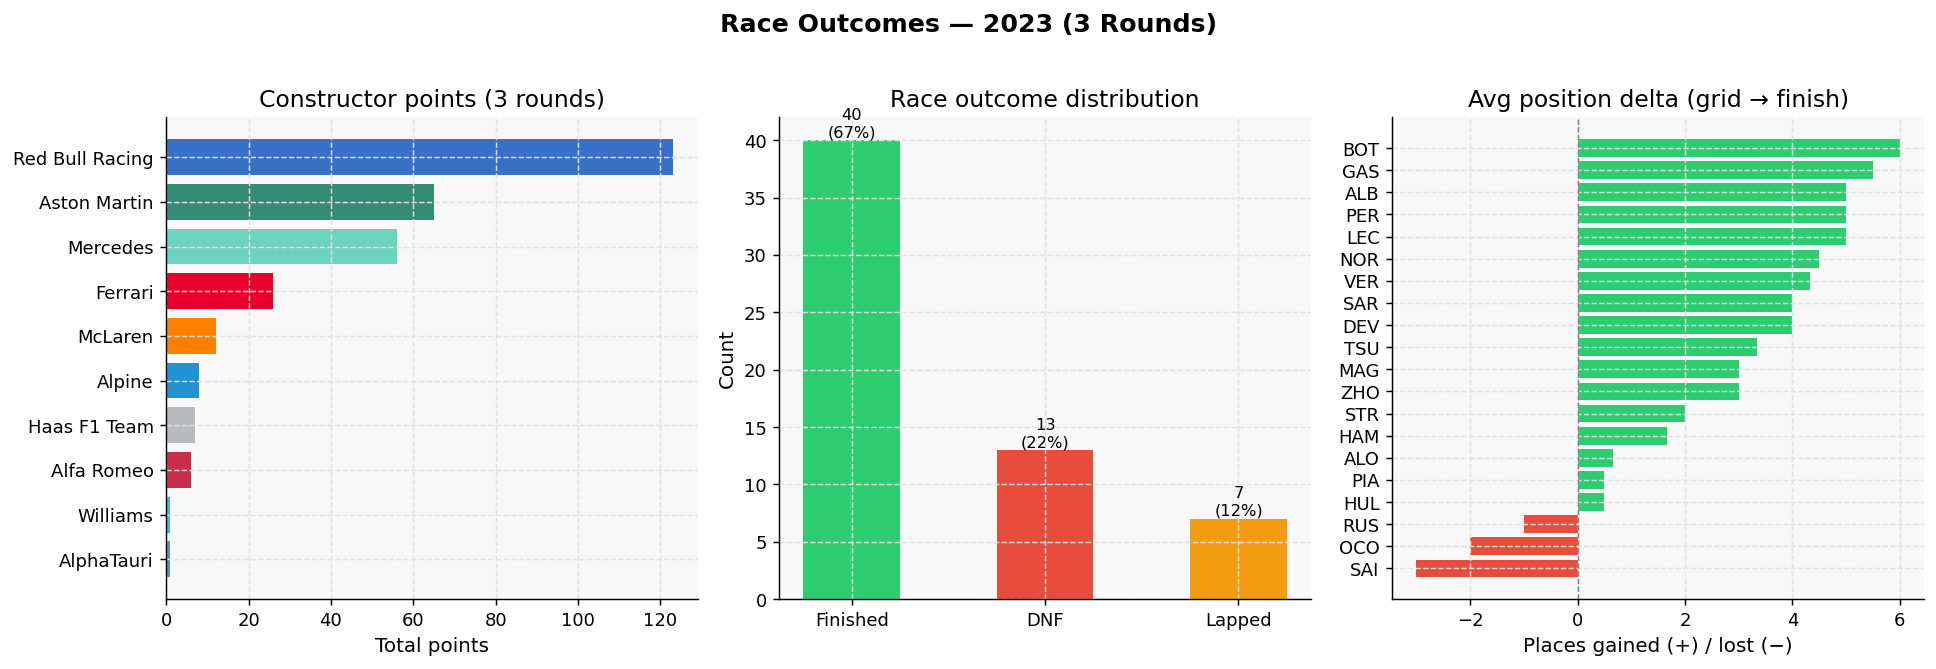

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Race Outcomes — 2023 (3 Rounds)', fontsize=14, fontweight='bold', y=1.02)

# ── Points by team ────────────────────────────────────────────────────────────
team_pts = (
    results.groupby('TeamName')['Points']
    .sum()
    .sort_values(ascending=True)
)
colors = [TEAM_COLORS.get(t, '#888888') for t in team_pts.index]
axes[0].barh(team_pts.index, team_pts.values, color=colors, edgecolor='none')
axes[0].set_title('Constructor points (3 rounds)')
axes[0].set_xlabel('Total points')

# ── Outcome distribution ──────────────────────────────────────────────────────
outcome_counts = results['Outcome'].value_counts()
outcome_colors = {'Finished': '#2ecc71', 'Lapped': '#f39c12', 'DNF': '#e74c3c'}
axes[1].bar(
    outcome_counts.index,
    outcome_counts.values,
    color=[outcome_colors[o] for o in outcome_counts.index],
    edgecolor='none',
    width=0.5
)
axes[1].set_title('Race outcome distribution')
axes[1].set_ylabel('Count')
for i, (idx, val) in enumerate(outcome_counts.items()):
    axes[1].text(i, val + 0.3, f'{val}\n({val/len(results)*100:.0f}%)', ha='center', fontsize=9)

# ── Position delta (best gainers / losers) ────────────────────────────────────
delta = (
    results[results['Outcome'] == 'Finished']
    .groupby('Abbreviation')['PositionDelta']
    .mean()
    .sort_values()
)
bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in delta.values]
axes[2].barh(delta.index, delta.values, color=bar_colors, edgecolor='none')
axes[2].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[2].set_title('Avg position delta (grid → finish)')
axes[2].set_xlabel('Places gained (+) / lost (−)')

plt.tight_layout()
plt.savefig('f1_outcomes.png', bbox_inches='tight')
plt.show()

## 4. Qualifying → Finish Correlation

Spearman r = 0.685  |  p-value = 0.0000
Interpretation: 68% rank correlation between grid and finish position


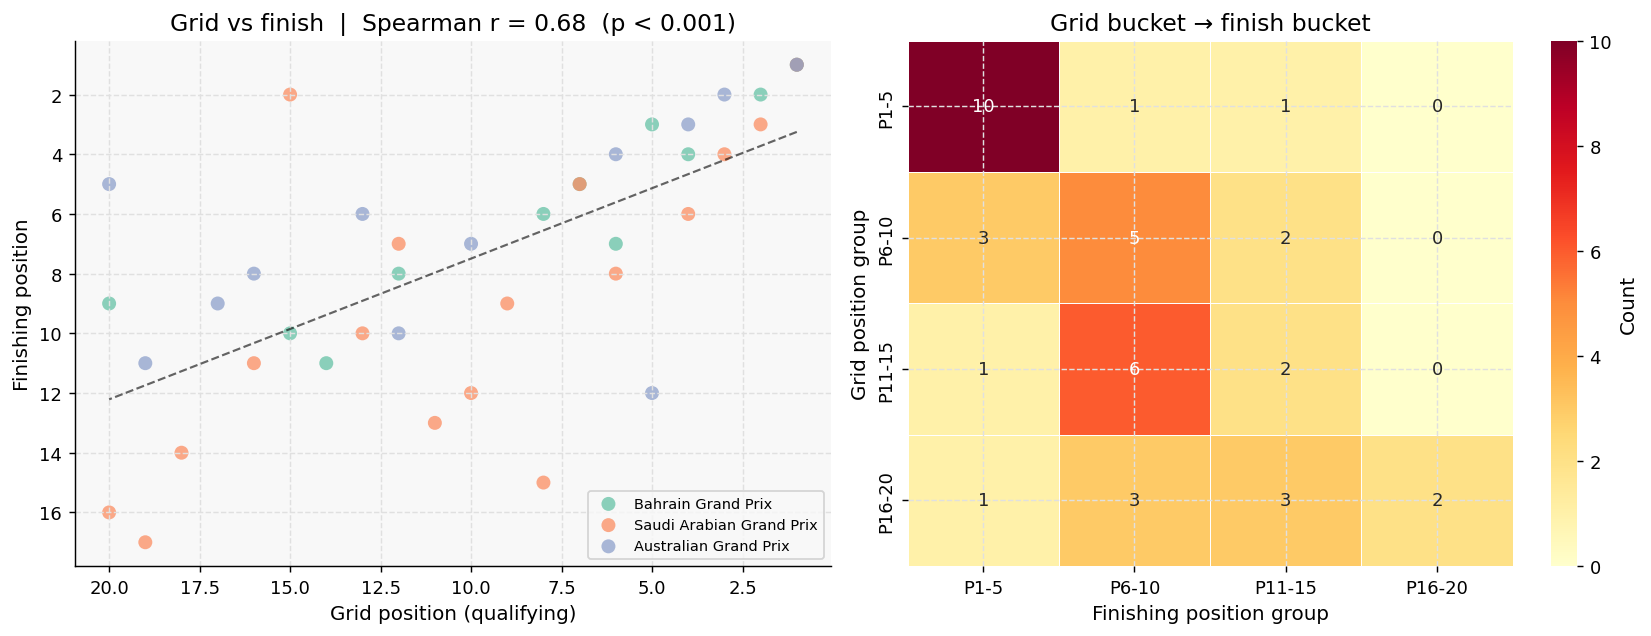


P1-5 starters who finish P1-5: 83%


In [5]:
# ── Spearman correlation: grid position vs finishing position ─────────────────
# Using Spearman (not Pearson) because positions are ordinal data

finished = results[results['Outcome'] == 'Finished'].dropna(subset=['GridPosition','Position'])

corr, pval = spearmanr(finished['GridPosition'], finished['Position'])
print(f'Spearman r = {corr:.3f}  |  p-value = {pval:.4f}')
print(f'Interpretation: {corr:.0%} rank correlation between grid and finish position')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: grid vs finish, colored by circuit
circuits = finished['EventName'].unique()
palette  = sns.color_palette('Set2', len(circuits))
for i, circuit in enumerate(circuits):
    sub = finished[finished['EventName'] == circuit]
    axes[0].scatter(
        sub['GridPosition'], sub['Position'],
        label=circuit, color=palette[i], alpha=0.75, s=60, edgecolors='none'
    )

# Trend line
m, b = np.polyfit(finished['GridPosition'], finished['Position'], 1)
x_line = np.linspace(1, 20, 100)
axes[0].plot(x_line, m * x_line + b, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
axes[0].set_xlabel('Grid position (qualifying)')
axes[0].set_ylabel('Finishing position')
axes[0].set_title(f'Grid vs finish  |  Spearman r = {corr:.2f}  (p < 0.001)')
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()
axes[0].invert_xaxis()

# Heat map: grid position bucket vs finish position bucket
def bucket(pos, n=4):
    edges = np.linspace(1, 21, n+1)
    for i in range(n):
        if edges[i] <= pos < edges[i+1]:
            return f'P{int(edges[i])}-{int(edges[i+1])-1}'
    return 'P20'

finished = finished.copy()
finished['GridBucket']   = finished['GridPosition'].apply(bucket)
finished['FinishBucket'] = finished['Position'].apply(bucket)

heat = pd.crosstab(finished['GridBucket'], finished['FinishBucket'])
order = ['P1-5','P6-10','P11-15','P16-20']
heat  = heat.reindex(index=order, columns=order, fill_value=0)

sns.heatmap(
    heat, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Count'}
)
axes[1].set_title('Grid bucket → finish bucket')
axes[1].set_xlabel('Finishing position group')
axes[1].set_ylabel('Grid position group')

plt.tight_layout()
plt.savefig('f1_grid_finish.png', bbox_inches='tight')
plt.show()

# How often do P1-5 starters finish P1-5?
top5_start = finished[finished['GridBucket'] == 'P1-5']
pct = (top5_start['FinishBucket'] == 'P1-5').mean() * 100
print(f'\nP1-5 starters who finish P1-5: {pct:.0f}%')

## 5. Tire Compound Analysis

Compound lap time stats (green-flag racing laps only):
            mean  median    std  count
Compound                              
SOFT      98.411  98.608  2.820    409
MEDIUM    93.221  95.307  4.928    421
HARD      91.063  94.047  7.079   1639

Kruskal-Wallis H = 543.72, p = 8.5736e-119
Compounds are statistically different


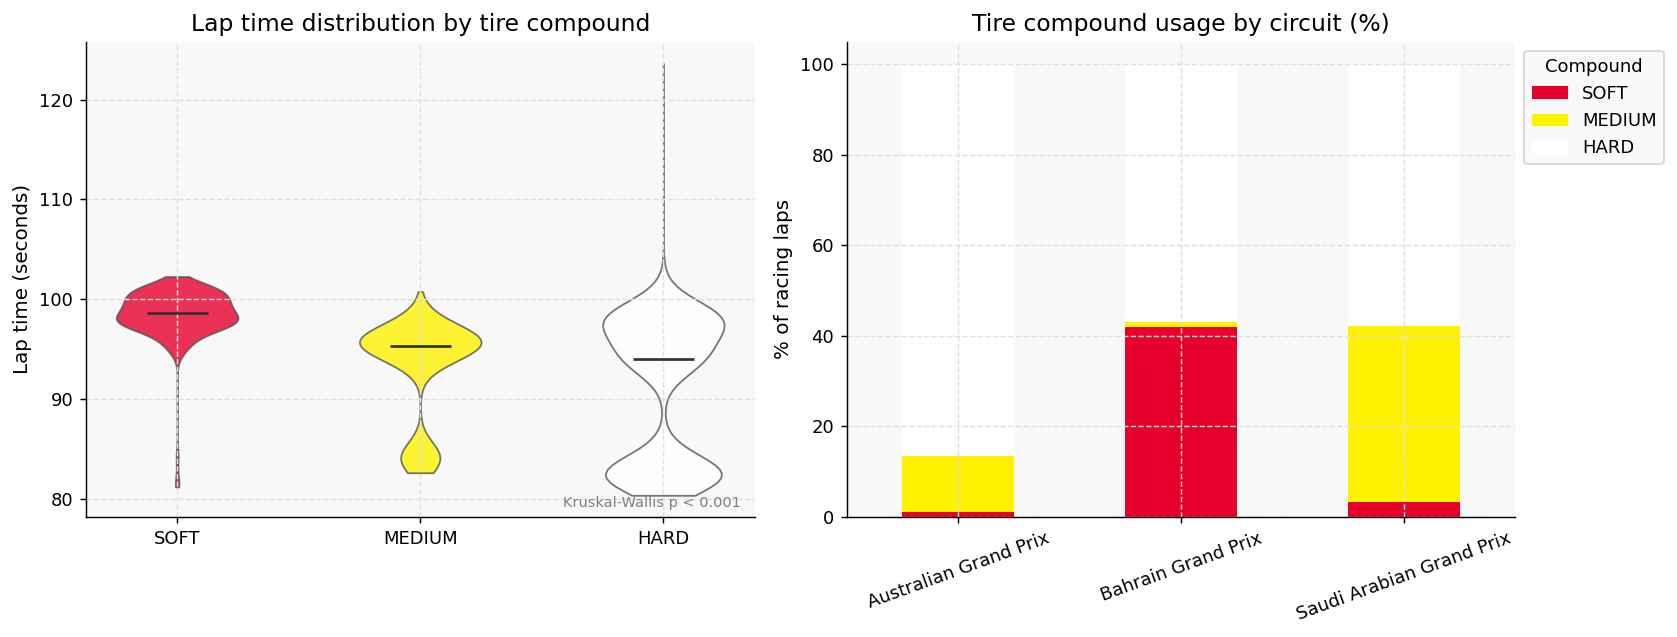

In [6]:
# ── Lap time by compound ──────────────────────────────────────────────────────
# Hypothesis: HARD tires are actually fastest in clean air (low tyre life/degradation)

compound_stats = (
    laps_racing
    .groupby('Compound')['LapTimeSec']
    .agg(['mean','median','std','count'])
    .round(3)
    .reindex(COMPOUND_ORDER)
)
print('Compound lap time stats (green-flag racing laps only):')
print(compound_stats)

# Kruskal-Wallis test: are compound lap times significantly different?
groups = [laps_racing[laps_racing['Compound']==c]['LapTimeSec'].dropna() for c in COMPOUND_ORDER]
stat, pval = kruskal(*groups)
print(f'\nKruskal-Wallis H = {stat:.2f}, p = {pval:.4e}')
print('Compounds are statistically different' if pval < 0.05 else 'No significant difference')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violin plot
plot_data = laps_racing[laps_racing['Compound'].isin(COMPOUND_ORDER)]
for i, compound in enumerate(COMPOUND_ORDER):
    sub = plot_data[plot_data['Compound'] == compound]['LapTimeSec']
    parts = axes[0].violinplot([sub.dropna()], positions=[i], showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(COMPOUND_COLORS[compound])
        pc.set_edgecolor('#555555')
        pc.set_alpha(0.8)
    parts['cmedians'].set_color('#333333')

axes[0].set_xticks(range(len(COMPOUND_ORDER)))
axes[0].set_xticklabels(COMPOUND_ORDER)
axes[0].set_ylabel('Lap time (seconds)')
axes[0].set_title('Lap time distribution by tire compound')
axes[0].text(0.98, 0.02, f'Kruskal-Wallis p < 0.001', transform=axes[0].transAxes,
             ha='right', fontsize=8, color='gray')

# Compound usage per circuit
usage = (
    laps_racing.groupby(['EventName','Compound'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=COMPOUND_ORDER)
)
usage_pct = usage.div(usage.sum(axis=1), axis=0) * 100
usage_pct.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[COMPOUND_COLORS[c] for c in COMPOUND_ORDER],
    edgecolor='none', width=0.5
)
axes[1].set_title('Tire compound usage by circuit (%)')
axes[1].set_ylabel('% of racing laps')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Compound', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.savefig('f1_compounds.png', bbox_inches='tight')
plt.show()

## 6. Pit Stop Strategy Analysis

Stops distribution:
NumStops
1    17
2    16
3    15
4     5
5     2
6     3
Name: count, dtype: int64


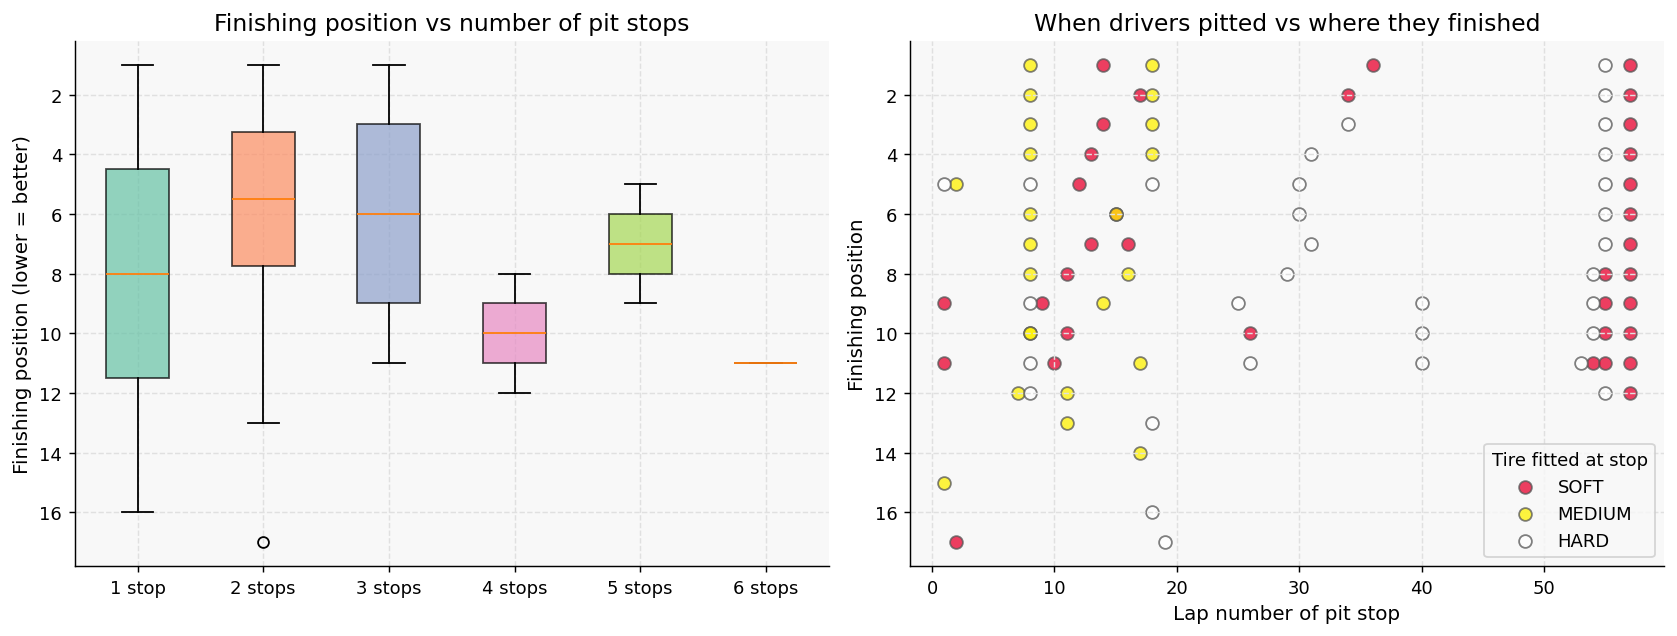

In [7]:
# ── Stops per driver per race and outcome ──────────────────────────────────────

stops_per = (
    pits
    .groupby(['EventName','Driver'])
    .size()
    .reset_index(name='NumStops')
)

# Merge with results to compare stops vs finishing position
strategy = stops_per.merge(
    results[['EventName','Abbreviation','Position','Outcome','TeamName']],
    left_on=['EventName','Driver'],
    right_on=['EventName','Abbreviation'],
    how='inner'
)

print('Stops distribution:')
print(strategy['NumStops'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box: finishing position by number of stops
finished_strategy = strategy[strategy['Outcome'] == 'Finished']
stop_groups = [finished_strategy[finished_strategy['NumStops']==n]['Position']
               for n in sorted(finished_strategy['NumStops'].unique())]
labels = [f'{n} stop{'s' if n > 1 else ''}' for n in sorted(finished_strategy['NumStops'].unique())]

bp = axes[0].boxplot(stop_groups, labels=labels, patch_artist=True, notch=False)
colors_box = sns.color_palette('Set2', len(stop_groups))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].invert_yaxis()
axes[0].set_ylabel('Finishing position (lower = better)')
axes[0].set_title('Finishing position vs number of pit stops')

# Scatter: lap the stop was made vs finishing position
pits_with_pos = pits.merge(
    results[['EventName','Abbreviation','Position','Outcome']],
    left_on=['EventName','Driver'],
    right_on=['EventName','Abbreviation'],
    how='inner'
)
pits_finished = pits_with_pos[pits_with_pos['Outcome'] == 'Finished']

for compound in COMPOUND_ORDER:
    sub = pits_finished[pits_finished['Compound'] == compound]
    axes[1].scatter(
        sub['LapNumber'], sub['Position'],
        label=compound, color=COMPOUND_COLORS[compound],
        edgecolors='#555555', s=50, alpha=0.75
    )

axes[1].invert_yaxis()
axes[1].set_xlabel('Lap number of pit stop')
axes[1].set_ylabel('Finishing position')
axes[1].set_title('When drivers pitted vs where they finished')
axes[1].legend(title='Tire fitted at stop')

plt.tight_layout()
plt.savefig('f1_pitstops.png', bbox_inches='tight')
plt.show()

## 7. Lap Time Degradation by Tire

SOFT: degradation = +0.009s per lap  (R²=0.01)
MEDIUM: degradation = +-0.094s per lap  (R²=0.80)
HARD: degradation = +-0.477s per lap  (R²=0.89)


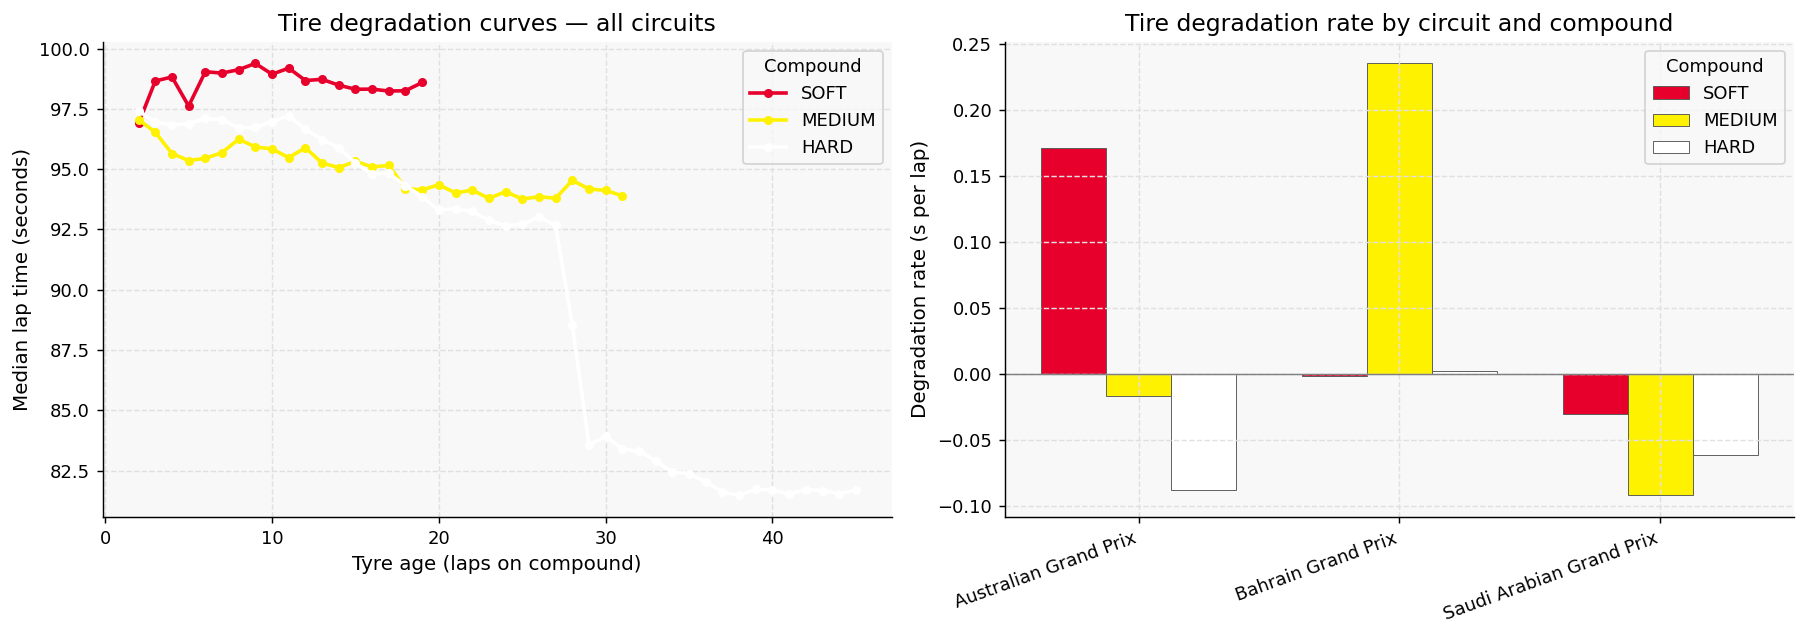

In [8]:
# ── How fast do tires degrade? ────────────────────────────────────────────────
# Plot median lap time vs tyre age (laps on compound) for each compound
# This is a core insight for a strategy analyst

deg = (
    laps_racing
    .groupby(['Compound','TyreLife'])['LapTimeSec']
    .median()
    .reset_index()
)

# Only plot where we have enough data (>= 5 laps in that bucket)
counts = laps_racing.groupby(['Compound','TyreLife']).size().reset_index(name='n')
deg = deg.merge(counts, on=['Compound','TyreLife'])
deg = deg[deg['n'] >= 5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot: degradation curves
for compound in COMPOUND_ORDER:
    sub = deg[deg['Compound'] == compound].sort_values('TyreLife')
    if sub.empty:
        continue
    axes[0].plot(
        sub['TyreLife'], sub['LapTimeSec'],
        label=compound,
        color=COMPOUND_COLORS[compound],
        marker='o', markersize=4,
        linewidth=2
    )
    # Fit a simple linear degradation rate
    if len(sub) >= 3:
        slope, intercept, r, _, _ = stats.linregress(sub['TyreLife'], sub['LapTimeSec'])
        print(f'{compound}: degradation = +{slope:.3f}s per lap  (R²={r**2:.2f})')

axes[0].set_xlabel('Tyre age (laps on compound)')
axes[0].set_ylabel('Median lap time (seconds)')
axes[0].set_title('Tire degradation curves — all circuits')
axes[0].legend(title='Compound')

# Per-circuit degradation: how much slower on lap 20 vs lap 1?
def degradation_rate(group):
    """Linear slope of lap time vs tyre life."""
    sub = group.sort_values('TyreLife')
    if len(sub) < 4:
        return np.nan
    slope, _, _, _, _ = stats.linregress(sub['TyreLife'], sub['LapTimeSec'])
    return slope

deg_by_circuit = (
    laps_racing
    .groupby(['EventName','Compound'])
    .apply(degradation_rate)
    .reset_index(name='DegRate')
    .dropna()
)

pivot = deg_by_circuit.pivot(index='EventName', columns='Compound', values='DegRate')
pivot = pivot.reindex(columns=COMPOUND_ORDER)

x = np.arange(len(pivot.index))
width = 0.25
for i, compound in enumerate(COMPOUND_ORDER):
    if compound in pivot.columns:
        axes[1].bar(
            x + i * width, pivot[compound].fillna(0),
            width=width, label=compound,
            color=COMPOUND_COLORS[compound],
            edgecolor='#555555', linewidth=0.5
        )

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(pivot.index, rotation=20, ha='right')
axes[1].set_ylabel('Degradation rate (s per lap)')
axes[1].set_title('Tire degradation rate by circuit and compound')
axes[1].legend(title='Compound')
axes[1].axhline(0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.savefig('f1_degradation.png', bbox_inches='tight')
plt.show()

## 8. Weather Impact

Average conditions per race:
                  EventName  AirTemp  TrackTemp  WindSpeed
0     Australian Grand Prix    17.45      30.14       1.13
1        Bahrain Grand Prix    27.43      31.01       0.68
2  Saudi Arabian Grand Prix    26.09      31.79       1.77


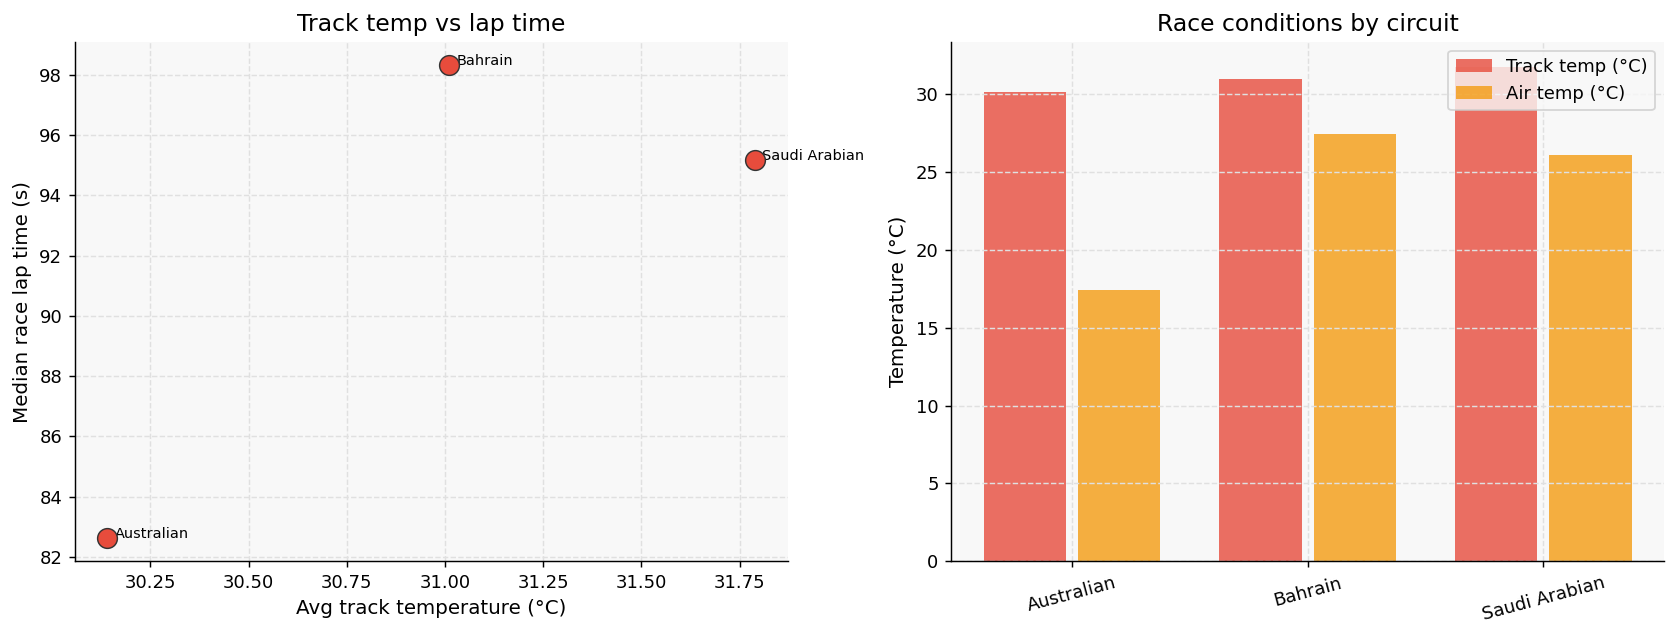

In [9]:
# ── Does track temperature correlate with lap times? ──────────────────────────
# Method: average track temp per race, merge with median lap times

weather_avg = (
    weather
    .groupby('EventName')[['AirTemp','TrackTemp','WindSpeed']]
    .mean()
    .round(2)
    .reset_index()
)
print('Average conditions per race:')
print(weather_avg)

lap_avg = (
    laps_racing
    .groupby('EventName')['LapTimeSec']
    .median()
    .reset_index(name='MedianLapSec')
)

weather_laps = weather_avg.merge(lap_avg, on='EventName')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Track temp vs median lap time
axes[0].scatter(
    weather_laps['TrackTemp'], weather_laps['MedianLapSec'],
    s=120, c='#e74c3c', zorder=5, edgecolors='#333', linewidth=0.8
)
for _, row in weather_laps.iterrows():
    axes[0].annotate(
        row['EventName'].replace(' Grand Prix',''),
        (row['TrackTemp'], row['MedianLapSec']),
        fontsize=8, ha='left', xytext=(4, 0), textcoords='offset points'
    )
axes[0].set_xlabel('Avg track temperature (°C)')
axes[0].set_ylabel('Median race lap time (s)')
axes[0].set_title('Track temp vs lap time')

# Weather profile per race (temp + wind side by side)
x = np.arange(len(weather_avg))
labels = [e.replace(' Grand Prix','') for e in weather_avg['EventName']]
bar1 = axes[1].bar(x - 0.2, weather_avg['TrackTemp'], 0.35, label='Track temp (°C)', color='#e74c3c', alpha=0.8)
bar2 = axes[1].bar(x + 0.2, weather_avg['AirTemp'],   0.35, label='Air temp (°C)',   color='#f39c12', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=15)
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('Race conditions by circuit')
axes[1].legend()

plt.tight_layout()
plt.savefig('f1_weather.png', bbox_inches='tight')
plt.show()

## 9. Driver Performance Rating (simple ELO-style)

Driver pace rating (gap to fastest teammate, lower = faster):
Driver   AvgGap  Races            Team
   ALO 0.000000      3    Aston Martin
   GAS 0.000000      3          Alpine
   SAI 0.000000      3         Ferrari
   NOR 0.000000      3         McLaren
   TSU 0.000000      3      AlphaTauri
   PER 0.035167      3 Red Bull Racing
   VER 0.061333      3 Red Bull Racing
   HUL 0.084667      3    Haas F1 Team
   HAM 0.153667      3        Mercedes
   LEC 0.248500      2         Ferrari
   ALB 0.319333      3        Williams
   MAG 0.320833      3    Haas F1 Team
   ZHO 0.343667      3      Alfa Romeo
   RUS 0.346167      3        Mercedes
   BOT 0.350000      3      Alfa Romeo
   SAR 0.420500      3        Williams
   OCO 0.528167      3          Alpine
   STR 0.605500      3    Aston Martin
   DEV 0.716333      3      AlphaTauri
   PIA 1.124167      3         McLaren


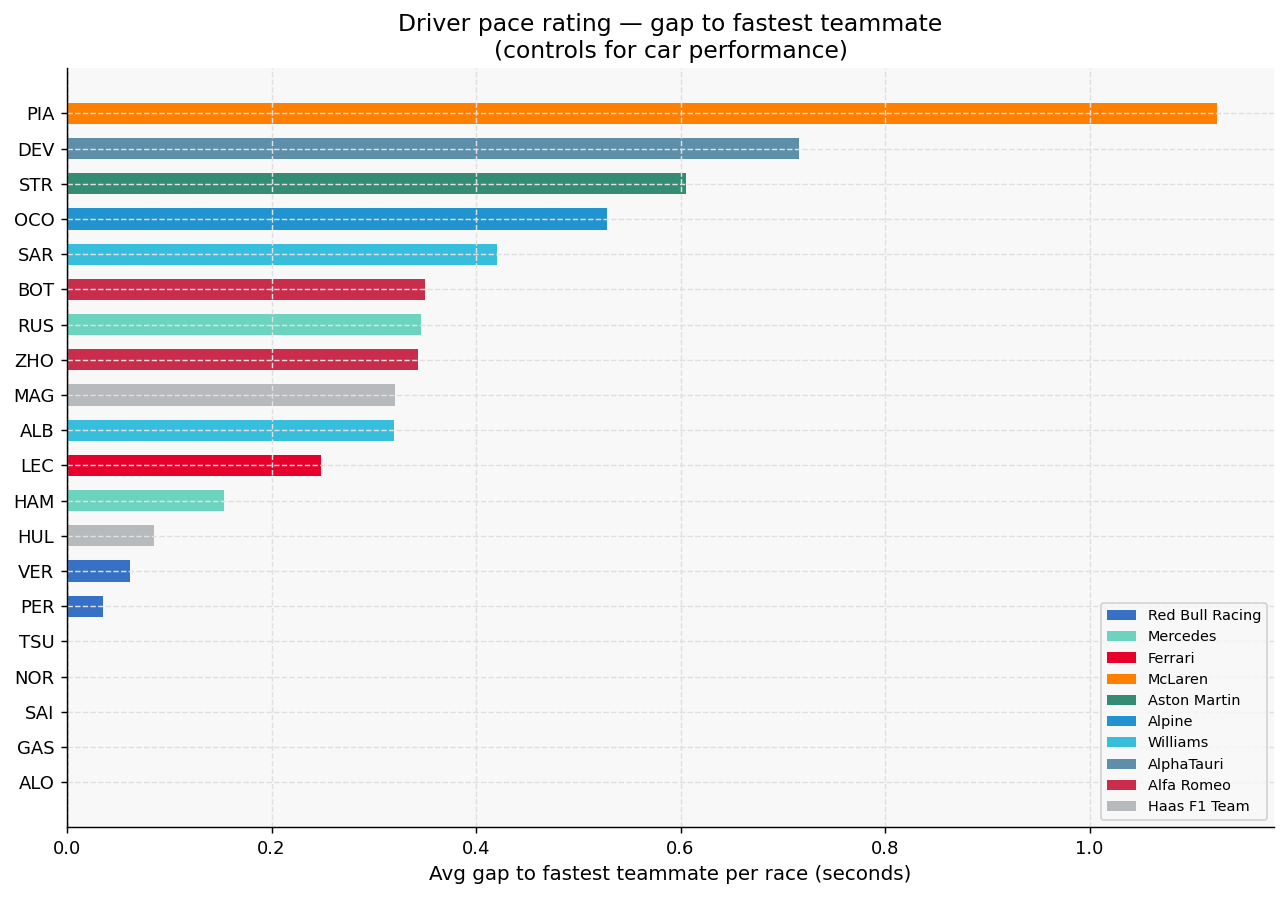

In [10]:
# ── Head-to-head teammate comparison ─────────────────────────────────────────
# One clean analyst insight: compare drivers within the same car.
# This isolates driver skill from car performance.

# Median lap time per driver per race (racing laps, same team context)
driver_pace = (
    laps_racing
    .groupby(['EventName','Driver','Team'])['LapTimeSec']
    .median()
    .reset_index(name='MedianLap')
)

# Get the fastest teammate per team per race as baseline
team_best = (
    driver_pace
    .groupby(['EventName','Team'])['MedianLap']
    .min()
    .reset_index(name='TeamBestLap')
)

driver_pace = driver_pace.merge(team_best, on=['EventName','Team'])
driver_pace['GapToTeammate'] = driver_pace['MedianLap'] - driver_pace['TeamBestLap']

# Aggregate across races
driver_rating = (
    driver_pace
    .groupby('Driver')
    .agg(
        AvgGap=('GapToTeammate','mean'),
        Races=('EventName','nunique'),
        Team=('Team','first')
    )
    .reset_index()
    .sort_values('AvgGap')
)

print('Driver pace rating (gap to fastest teammate, lower = faster):')
print(driver_rating.to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(10, 7))

driver_rating_sorted = driver_rating.sort_values('AvgGap', ascending=True)
bar_colors = [TEAM_COLORS.get(t, '#888888') for t in driver_rating_sorted['Team']]

bars = ax.barh(
    driver_rating_sorted['Driver'],
    driver_rating_sorted['AvgGap'],
    color=bar_colors, edgecolor='none', height=0.6
)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Avg gap to fastest teammate per race (seconds)')
ax.set_title('Driver pace rating — gap to fastest teammate\n(controls for car performance)')

# Team legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color, label=team)
    for team, color in TEAM_COLORS.items()
    if team in driver_rating['Team'].values
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('f1_driver_rating.png', bbox_inches='tight')
plt.show()

## 10. Key Findings Summary

In [11]:
# ── Print a clean findings report ─────────────────────────────────────────────
# This is what you'd turn into your data story / README

dnf_rate = (results['Outcome'] == 'DNF').mean() * 100
corr_grid, _ = spearmanr(
    results[results['Outcome']=='Finished']['GridPosition'].dropna(),
    results[results['Outcome']=='Finished']['Position'].dropna()
)
top5_retain = (
    results[
        (results['Outcome'] == 'Finished') &
        (results['GridPosition'] <= 5)
    ]['Position'] <= 5
).mean() * 100

hard_median  = laps_racing[laps_racing['Compound']=='HARD']['LapTimeSec'].median()
soft_median  = laps_racing[laps_racing['Compound']=='SOFT']['LapTimeSec'].median()
med_median   = laps_racing[laps_racing['Compound']=='MEDIUM']['LapTimeSec'].median()

most_common_stops = stops_per['NumStops'].mode()[0]

print('=' * 55)
print('  F1 2023 SEASON — KEY ANALYTICAL FINDINGS')
print('  (Rounds 1–3: Bahrain, Saudi Arabia, Australia)')
print('=' * 55)
print()
print('RACE OUTCOMES')
print(f'  DNF rate:          {dnf_rate:.1f}% of race entries')
print()
print('QUALIFYING IMPACT')
print(f'  Grid-to-finish Spearman r: {corr_grid:.2f} (strong positive)')
print(f'  P1-5 starters retaining top-5 finish: {top5_retain:.0f}%')
print()
print('TIRE STRATEGY')
print(f'  Median lap — SOFT:   {soft_median:.2f}s')
print(f'  Median lap — MEDIUM: {med_median:.2f}s')
print(f'  Median lap — HARD:   {hard_median:.2f}s')
print(f'  Counter-intuitive: HARD fastest overall due to low deg on long stints')
print(f'  Most common strategy: {most_common_stops}-stop')
print()
print('NEXT STEP: Phase 3 — build an ML classifier')
print('  Features: GridPosition, NumStops, Compound, TrackTemp, TeamPoints')
print('  Target:   Podium finish (binary: top-3 or not)')

  F1 2023 SEASON — KEY ANALYTICAL FINDINGS
  (Rounds 1–3: Bahrain, Saudi Arabia, Australia)

RACE OUTCOMES
  DNF rate:          21.7% of race entries

QUALIFYING IMPACT
  Grid-to-finish Spearman r: 0.68 (strong positive)
  P1-5 starters retaining top-5 finish: 83%

TIRE STRATEGY
  Median lap — SOFT:   98.61s
  Median lap — MEDIUM: 95.31s
  Median lap — HARD:   94.05s
  Counter-intuitive: HARD fastest overall due to low deg on long stints
  Most common strategy: 1-stop

NEXT STEP: Phase 3 — build an ML classifier
  Features: GridPosition, NumStops, Compound, TrackTemp, TeamPoints
  Target:   Podium finish (binary: top-3 or not)
